# IR Spectra: Exploration & ML Readiness

Explore the IR spectra downloaded from NIST WebBook for Keller 2016 odorants.
Check data quality and prepare an interpolated matrix suitable for ML.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")
df = pd.read_csv(DATA_DIR / "ir_spectra.csv")
molecules = pd.read_csv(DATA_DIR / "molecules.csv")
print(f"Loaded {len(df):,} spectral points from {df['CID'].nunique()} molecules")
print(f"Keller 2016 has {len(molecules)} molecules total")
print(f"Coverage: {df['CID'].nunique()}/{len(molecules)} ({100*df['CID'].nunique()/len(molecules):.1f}%)")
df.head()

Loaded 365,364 spectral points from 313 molecules
Keller 2016 has 481 molecules total
Coverage: 313/481 (65.1%)


,CID,name,cas,wavenumber_cm1,transmittance
0,520191,"3-Acetyl-2,5-dimethylthiophene",2530-10-1,549.900000,2.4038
1,520191,"3-Acetyl-2,5-dimethylthiophene",2530-10-1,551.829306,2.4048
2,520191,"3-Acetyl-2,5-dimethylthiophene",2530-10-1,553.758613,2.5900
3,520191,"3-Acetyl-2,5-dimethylthiophene",2530-10-1,555.687919,2.5212
4,520191,"3-Acetyl-2,5-dimethylthiophene",2530-10-1,557.617226,2.5515


## 1. Raw data overview

In [18]:
# Points per molecule and wavenumber ranges
grouped = df.groupby(["CID", "name"]).agg(
    n_points=("wavenumber_cm1", "size"),
    wn_min=("wavenumber_cm1", "min"),
    wn_max=("wavenumber_cm1", "max"),
    trans_min=("transmittance", "min"),
    trans_max=("transmittance", "max"),
).reset_index()

print("Points per spectrum:")
print(grouped["n_points"].describe().to_string())
print(f"\nWavenumber min range: {grouped['wn_min'].min():.1f} - {grouped['wn_min'].max():.1f} cm-1")
print(f"Wavenumber max range: {grouped['wn_max'].min():.1f} - {grouped['wn_max'].max():.1f} cm-1")

Points per spectrum:
count     313.000000
mean     1167.297125
std       753.235737
min       825.000000
25%       880.000000
50%       880.000000
75%       880.000000
max      5163.000000

Wavenumber min range: 2.0 - 668.0 cm-1
Wavenumber max range: 15.0 - 4016.0 cm-1


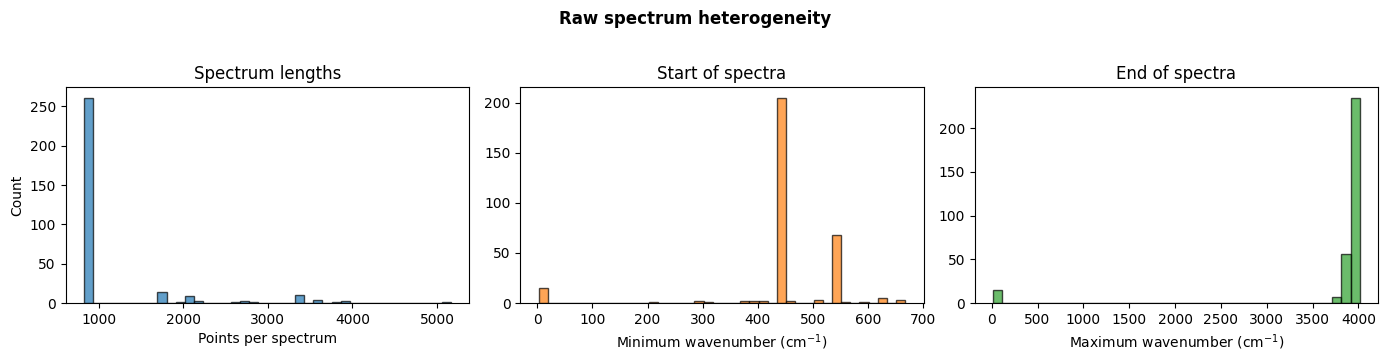

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].hist(grouped["n_points"], bins=40, edgecolor="k", alpha=0.7)
axes[0].set_xlabel("Points per spectrum")
axes[0].set_ylabel("Count")
axes[0].set_title("Spectrum lengths")

axes[1].hist(grouped["wn_min"], bins=40, edgecolor="k", alpha=0.7, color="C1")
axes[1].set_xlabel("Minimum wavenumber (cm$^{-1}$)")
axes[1].set_title("Start of spectra")

axes[2].hist(grouped["wn_max"], bins=40, edgecolor="k", alpha=0.7, color="C2")
axes[2].set_xlabel("Maximum wavenumber (cm$^{-1}$)")
axes[2].set_title("End of spectra")

fig.suptitle("Raw spectrum heterogeneity", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 2. Sample spectra

Plot a few well-known odorants to sanity-check the data.

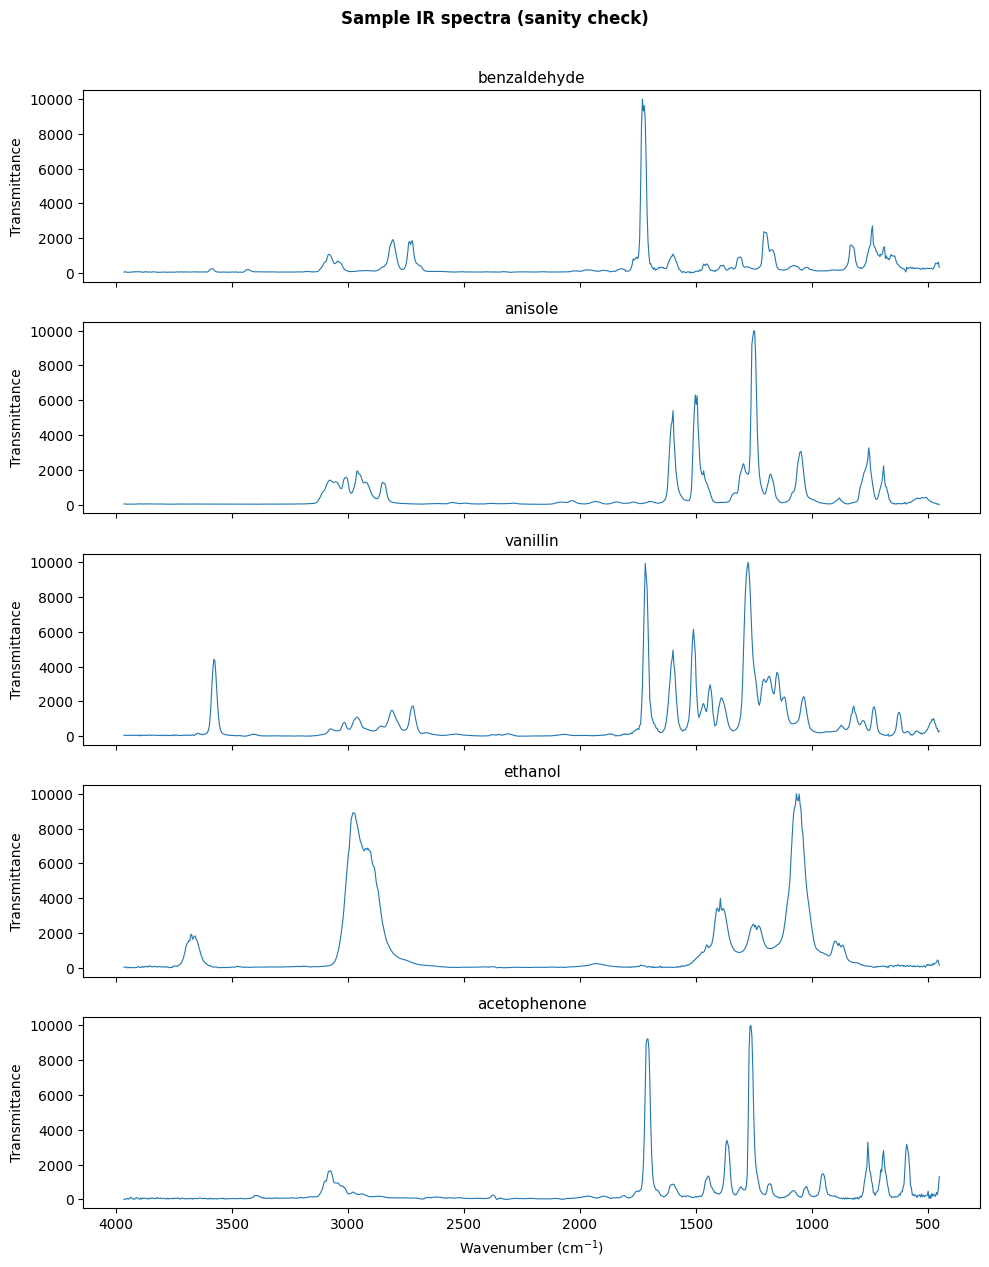

In [20]:
# Pick some recognizable molecules
sample_names = ["benzaldehyde", "anisole", "acetophenone", "vanillin", "ethanol", "limonene"]
available = df[df["name"].str.lower().isin(sample_names)]
sample_cids = available["CID"].unique()

fig, axes = plt.subplots(len(sample_cids), 1, figsize=(10, 2.5 * len(sample_cids)), sharex=True)
if len(sample_cids) == 1:
    axes = [axes]

for ax, cid in zip(axes, sample_cids):
    subset = df[df["CID"] == cid].sort_values("wavenumber_cm1")
    name = subset["name"].iloc[0]
    ax.plot(subset["wavenumber_cm1"], subset["transmittance"], lw=0.8)
    ax.set_ylabel("Transmittance")
    ax.set_title(name, fontsize=11)
    ax.invert_xaxis()  # IR convention: high wavenumber on left

axes[-1].set_xlabel("Wavenumber (cm$^{-1}$)")
fig.suptitle("Sample IR spectra (sanity check)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 3. Interpolate onto a common grid

For ML we need a fixed-length feature vector per molecule. Interpolate all spectra
onto a shared wavenumber grid within the range most spectra cover.

In [21]:
# Find a common range that most spectra cover
GRID_MIN = 600   # cm-1, safe lower bound for most spectra
GRID_MAX = 3900  # cm-1, safe upper bound
GRID_POINTS = 800  # ~4 cm-1 resolution

common_wn = np.linspace(GRID_MIN, GRID_MAX, GRID_POINTS)

# Check how many spectra actually span this range
covers_range = grouped[
    (grouped["wn_min"] <= GRID_MIN + 50) & (grouped["wn_max"] >= GRID_MAX - 50)
]
print(f"Grid: {GRID_MIN}-{GRID_MAX} cm-1, {GRID_POINTS} points")
print(f"Spectra covering this range: {len(covers_range)}/{len(grouped)} ({100*len(covers_range)/len(grouped):.1f}%)")

Grid: 600-3900 cm-1, 800 points
Spectra covering this range: 234/313 (74.8%)


In [22]:
# Interpolate each spectrum onto the common grid
spectra_matrix = {}
skipped = []

for cid, group in df.groupby("CID"):
    group = group.sort_values("wavenumber_cm1")
    wn = group["wavenumber_cm1"].values
    tr = group["transmittance"].values

    # Skip if spectrum doesn't cover our grid range
    if wn.min() > GRID_MIN + 50 or wn.max() < GRID_MAX - 50:
        skipped.append((cid, group["name"].iloc[0]))
        continue

    interp_tr = np.interp(common_wn, wn, tr)
    spectra_matrix[cid] = interp_tr

X = pd.DataFrame(spectra_matrix, index=common_wn).T
X.index.name = "CID"
X.columns = [f"{wn:.1f}" for wn in common_wn]

print(f"Interpolated matrix: {X.shape[0]} molecules x {X.shape[1]} features")
print(f"Skipped {len(skipped)} molecules (insufficient wavenumber range)")
if skipped:
    print("  Examples:", [s[1] for s in skipped[:5]])

Interpolated matrix: 234 molecules x 800 features
Skipped 79 molecules (insufficient wavenumber range)
  Examples: ['acetaldehyde', 'benzyl alcohol', 'butanediol', 'Citric acid', '4-Isopropylbenzyl alcohol']


## 4. Data quality checks

In [23]:
print("=" * 50)
print("ML READINESS CHECKS")
print("=" * 50)

# Check 1: uniform shape
print(f"\n1. Uniform shape: {X.shape} -- all rows are {X.shape[1]} features")

# Check 2: NaN / inf
n_nan = X.isna().sum().sum()
n_inf = np.isinf(X.values).sum()
print(f"2. NaN values: {n_nan}  |  Inf values: {n_inf}")

# Check 3: constant columns (zero variance)
col_var = X.var()
n_const = (col_var < 1e-10).sum()
print(f"3. Constant (zero-variance) features: {n_const}/{X.shape[1]}")

# Check 4: transmittance value range
vmin, vmax = X.values.min(), X.values.max()
print(f"4. Value range: [{vmin:.4f}, {vmax:.4f}]")

# Check 5: duplicate spectra
n_dup = X.duplicated().sum()
print(f"5. Duplicate spectra: {n_dup}")

# Check 6: highly correlated neighbors (expected for adjacent wavenumbers)
autocorr = np.array([np.corrcoef(X.iloc[:, i], X.iloc[:, i+1])[0, 1] for i in range(X.shape[1]-1)])
print(f"6. Mean adjacent-feature correlation: {autocorr.mean():.4f} (high is expected for spectra)")

print("\n" + "=" * 50)

ML READINESS CHECKS

1. Uniform shape: (234, 800) -- all rows are 800 features
2. NaN values: 0  |  Inf values: 0
3. Constant (zero-variance) features: 0/800
4. Value range: [0.0000, 9999.5588]
5. Duplicate spectra: 0
6. Mean adjacent-feature correlation: 0.9801 (high is expected for spectra)



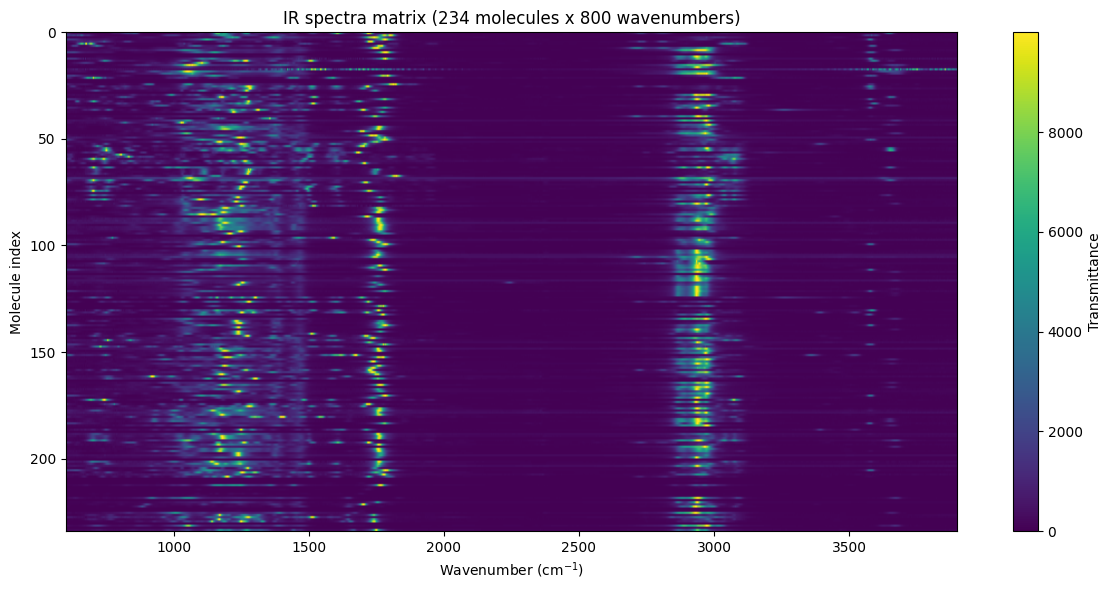

In [24]:
# Visualize the full spectra matrix as a heatmap
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(
    X.values,
    aspect="auto",
    cmap="viridis",
    extent=[GRID_MIN, GRID_MAX, X.shape[0], 0],
)
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Molecule index")
ax.set_title(f"IR spectra matrix ({X.shape[0]} molecules x {X.shape[1]} wavenumbers)")
plt.colorbar(im, ax=ax, label="Transmittance")
plt.tight_layout()
plt.show()

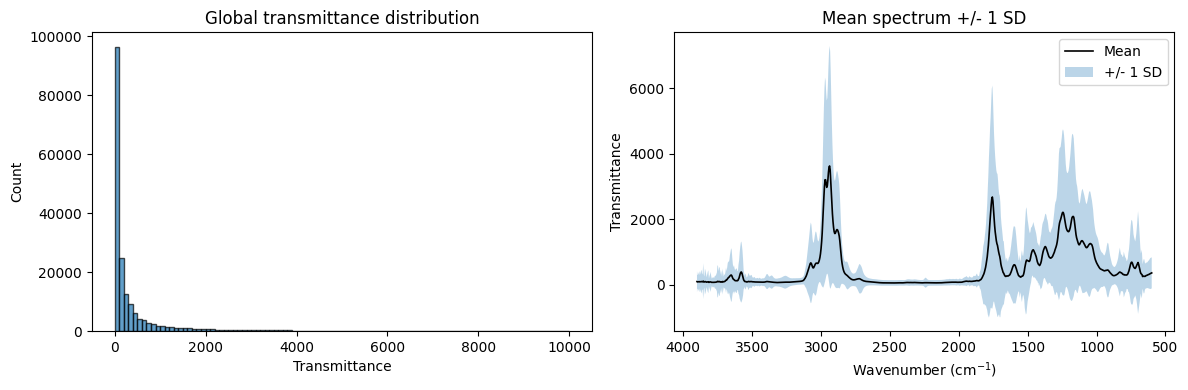

In [25]:
# Distribution of transmittance values across all spectra
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X.values.ravel(), bins=100, edgecolor="k", alpha=0.7)
axes[0].set_xlabel("Transmittance")
axes[0].set_ylabel("Count")
axes[0].set_title("Global transmittance distribution")

# Mean spectrum +/- std
mean_spec = X.values.mean(axis=0)
std_spec = X.values.std(axis=0)
axes[1].plot(common_wn, mean_spec, color="k", lw=1.2, label="Mean")
axes[1].fill_between(common_wn, mean_spec - std_spec, mean_spec + std_spec, alpha=0.3, label="+/- 1 SD")
axes[1].invert_xaxis()
axes[1].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[1].set_ylabel("Transmittance")
axes[1].set_title("Mean spectrum +/- 1 SD")
axes[1].legend()

plt.tight_layout()
plt.show()

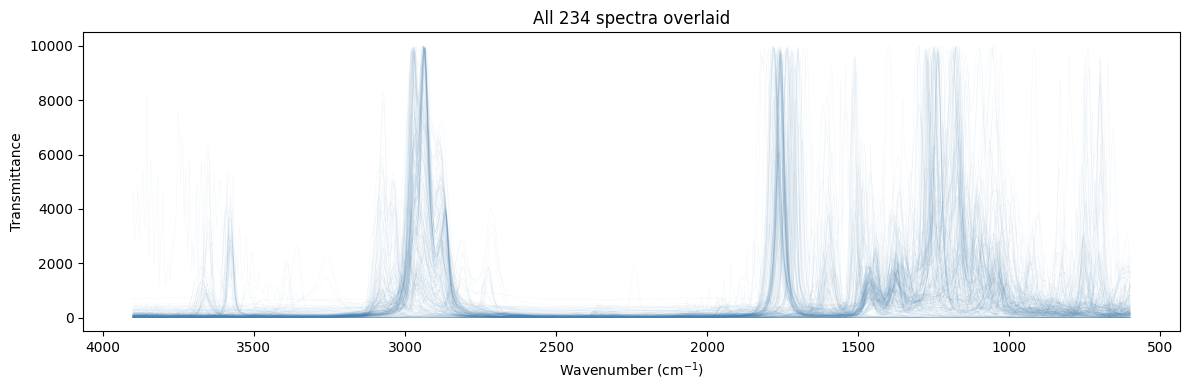

In [26]:
# Overlay all spectra to look for obvious outliers
fig, ax = plt.subplots(figsize=(12, 4))
for i in range(X.shape[0]):
    ax.plot(common_wn, X.values[i], alpha=0.05, color="steelblue", lw=0.5)
ax.invert_xaxis()
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Transmittance")
ax.set_title(f"All {X.shape[0]} spectra overlaid")
plt.tight_layout()
plt.show()

## 5. Log-scale views

The raw transmittance spans several orders of magnitude. Log transforms
reveal structure in the low-intensity regions and are standard in
spectroscopy (absorbance = -log10(T) when T is fractional).

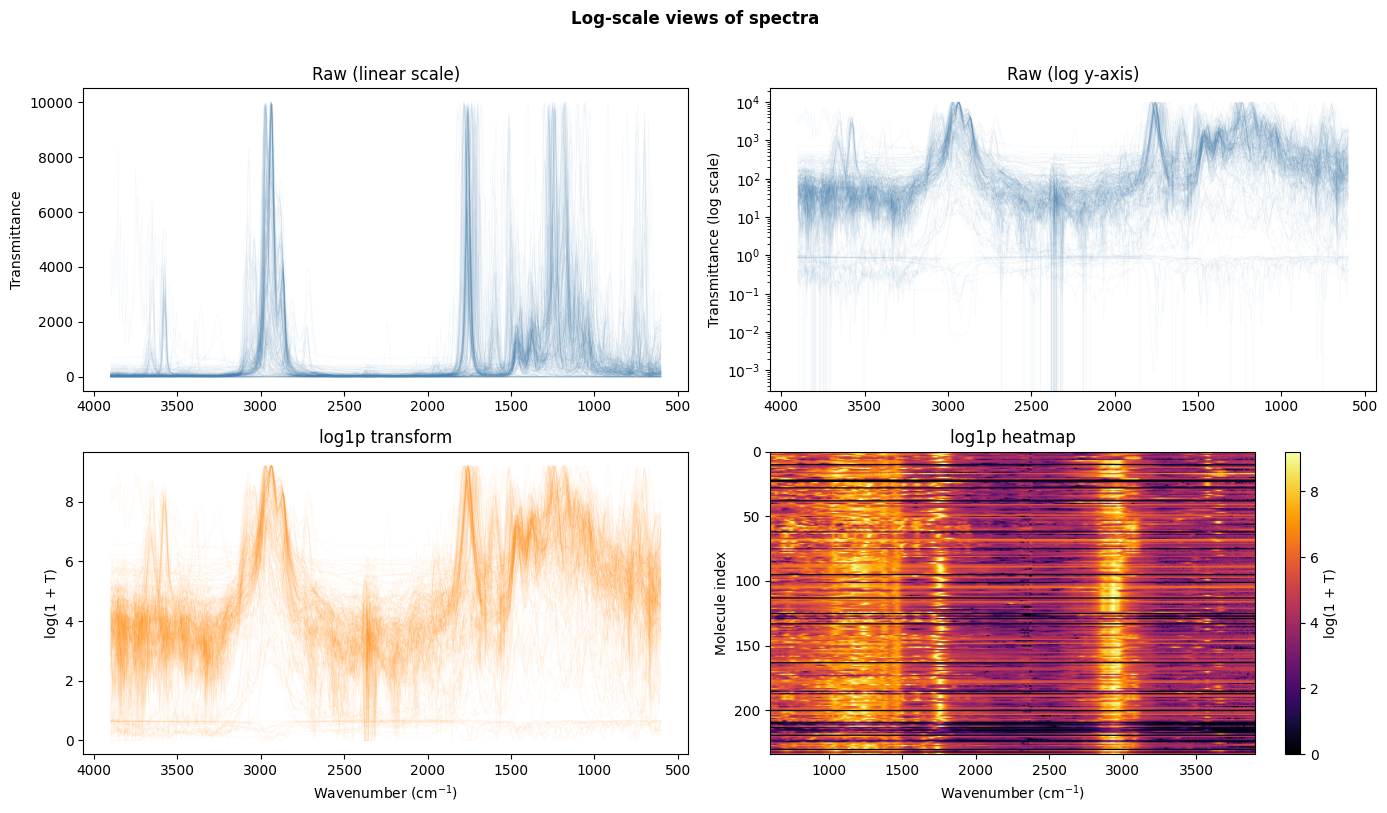

In [27]:
Xv = X.values

# log1p transform (safe for zeros)
X_log1p = np.log1p(Xv)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Top-left: raw overlay
for i in range(Xv.shape[0]):
    axes[0, 0].plot(common_wn, Xv[i], alpha=0.05, color="steelblue", lw=0.5)
axes[0, 0].invert_xaxis()
axes[0, 0].set_ylabel("Transmittance")
axes[0, 0].set_title("Raw (linear scale)")

# Top-right: raw with log y-axis
for i in range(Xv.shape[0]):
    axes[0, 1].plot(common_wn, Xv[i], alpha=0.05, color="steelblue", lw=0.5)
axes[0, 1].set_yscale("log")
axes[0, 1].invert_xaxis()
axes[0, 1].set_ylabel("Transmittance (log scale)")
axes[0, 1].set_title("Raw (log y-axis)")

# Bottom-left: log1p overlay
for i in range(X_log1p.shape[0]):
    axes[1, 0].plot(common_wn, X_log1p[i], alpha=0.05, color="darkorange", lw=0.5)
axes[1, 0].invert_xaxis()
axes[1, 0].set_ylabel("log(1 + T)")
axes[1, 0].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[1, 0].set_title("log1p transform")

# Bottom-right: log1p heatmap
im = axes[1, 1].imshow(
    X_log1p, aspect="auto", cmap="inferno",
    extent=[GRID_MIN, GRID_MAX, X_log1p.shape[0], 0],
)
axes[1, 1].set_xlabel("Wavenumber (cm$^{-1}$)")
axes[1, 1].set_ylabel("Molecule index")
axes[1, 1].set_title("log1p heatmap")
plt.colorbar(im, ax=axes[1, 1], label="log(1 + T)")

fig.suptitle("Log-scale views of spectra", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6. Normalization methods

Different normalizations suit different downstream tasks. We compare:

- **Min-max** (per spectrum to [0, 1]): preserves relative peak shapes, good for distance-based methods
- **SNV (Standard Normal Variate)**: per-spectrum z-score; standard in chemometrics for removing baseline/scale differences
- **L2 (unit vector)**: each spectrum becomes a unit vector; useful for cosine-similarity comparisons
- **Area normalization**: divide by integral under the curve; makes spectra comparable regardless of absolute intensity

In [28]:
# Compute all normalizations
Xv = X.values.copy()

# Min-max per spectrum
row_min = Xv.min(axis=1, keepdims=True)
row_max = Xv.max(axis=1, keepdims=True)
X_minmax = (Xv - row_min) / (row_max - row_min + 1e-10)

# SNV (Standard Normal Variate) -- per-spectrum z-score
row_mean = Xv.mean(axis=1, keepdims=True)
row_std = Xv.std(axis=1, keepdims=True)
X_snv = (Xv - row_mean) / (row_std + 1e-10)

# L2 normalization (unit vector)
row_norm = np.linalg.norm(Xv, axis=1, keepdims=True)
X_l2 = Xv / (row_norm + 1e-10)

# Area normalization (divide by trapezoidal integral)
areas = np.trapz(Xv, common_wn, axis=1)
X_area = Xv / (areas[:, None] + 1e-10)

norms = {
    "Min-max [0,1]": X_minmax,
    "SNV (z-score)": X_snv,
    "L2 (unit vector)": X_l2,
    "Area-normalized": X_area,
}

# Summary stats
print(f"{'Method':<20s} {'Min':>10s} {'Max':>10s} {'Mean':>10s} {'Std':>10s}")
print("-" * 62)
for name, arr in norms.items():
    print(f"{name:<20s} {arr.min():10.4f} {arr.max():10.4f} {arr.mean():10.4f} {arr.std():10.4f}")

Method                      Min        Max       Mean        Std
--------------------------------------------------------------
Min-max [0,1]            0.0000     1.0000     0.0950     0.2139
SNV (z-score)           -8.1723    12.4967     0.0000     1.0000
L2 (unit vector)         0.0000     0.4381     0.0158     0.0316
Area-normalized          0.0000     0.0163     0.0003     0.0007


C:\Users\Drago\AppData\Local\Temp\ipykernel_26252\2189126217.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  areas = np.trapz(Xv, common_wn, axis=1)


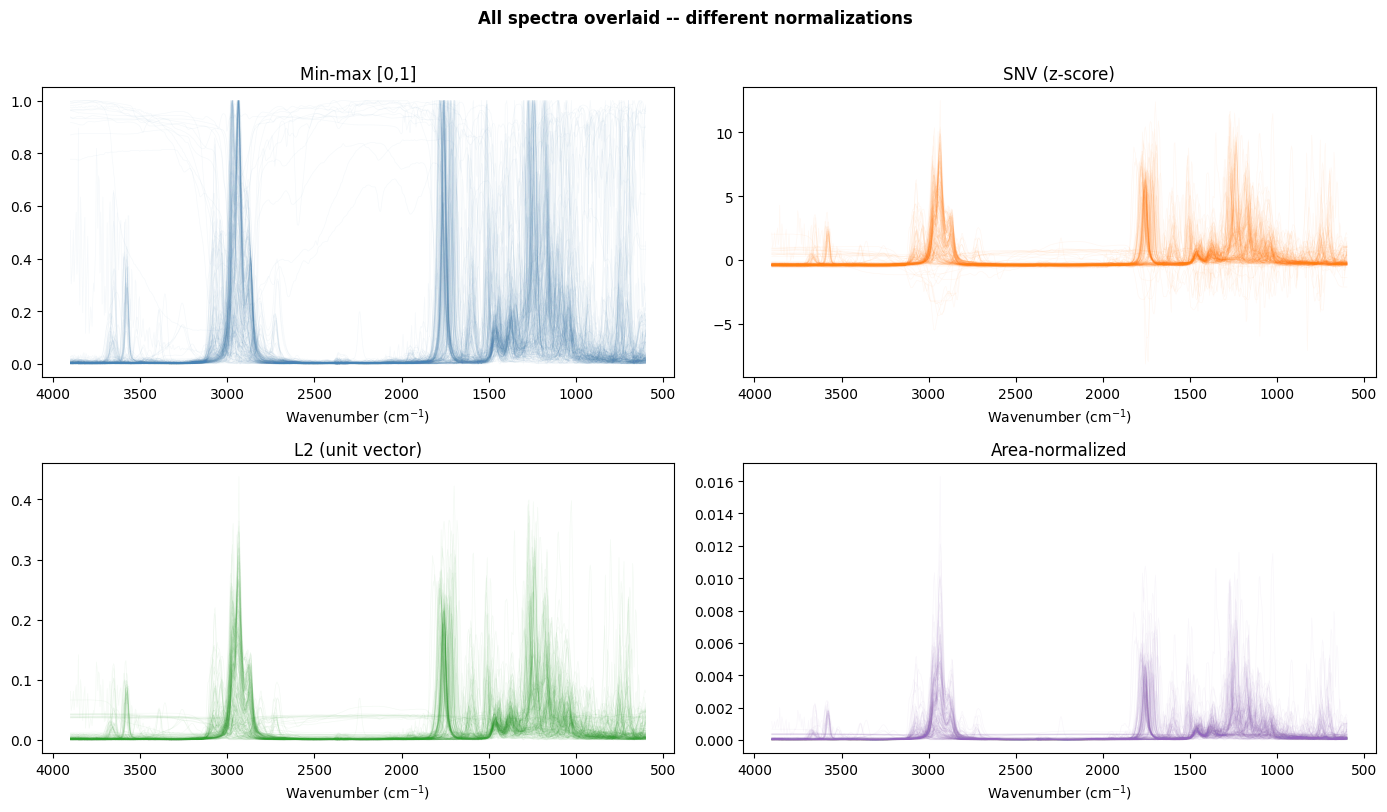

In [29]:
# Overlay all spectra under each normalization
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

colors = ["steelblue", "C1", "C2", "C4"]
for ax, (name, arr), c in zip(axes.ravel(), norms.items(), colors):
    for i in range(arr.shape[0]):
        ax.plot(common_wn, arr[i], alpha=0.05, lw=0.5, color=c)
    ax.invert_xaxis()
    ax.set_title(name)
    ax.set_xlabel("Wavenumber (cm$^{-1}$)")

fig.suptitle("All spectra overlaid -- different normalizations", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

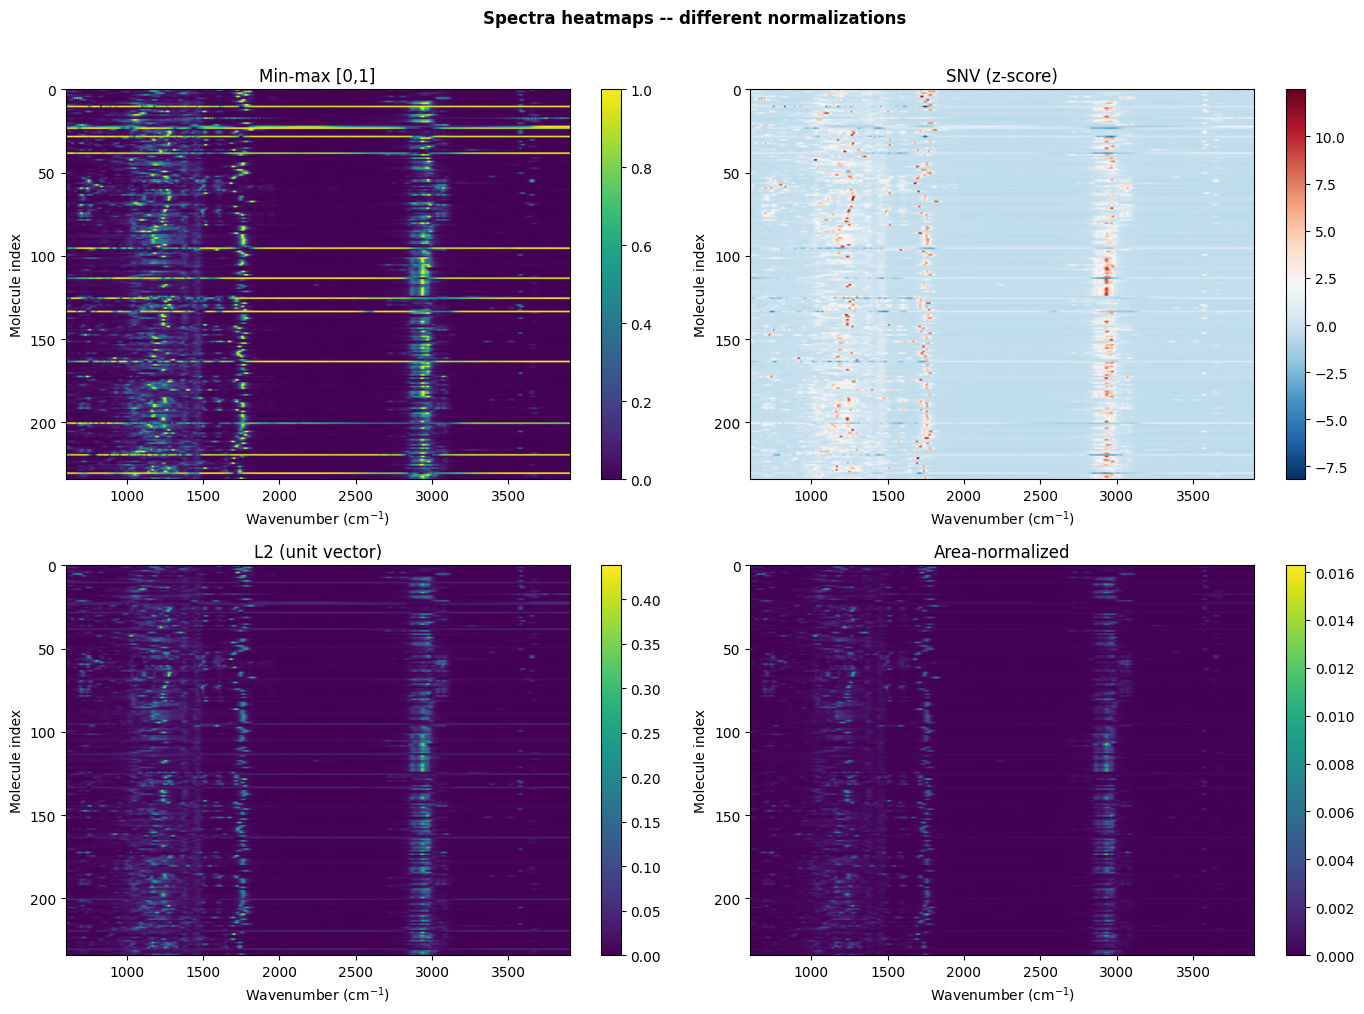

In [30]:
# Heatmaps for each normalization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cmaps = ["viridis", "RdBu_r", "viridis", "viridis"]
for ax, (name, arr), cmap in zip(axes.ravel(), norms.items(), cmaps):
    im = ax.imshow(
        arr, aspect="auto", cmap=cmap,
        extent=[GRID_MIN, GRID_MAX, arr.shape[0], 0],
    )
    ax.set_xlabel("Wavenumber (cm$^{-1}$)")
    ax.set_ylabel("Molecule index")
    ax.set_title(name)
    plt.colorbar(im, ax=ax)

fig.suptitle("Spectra heatmaps -- different normalizations", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

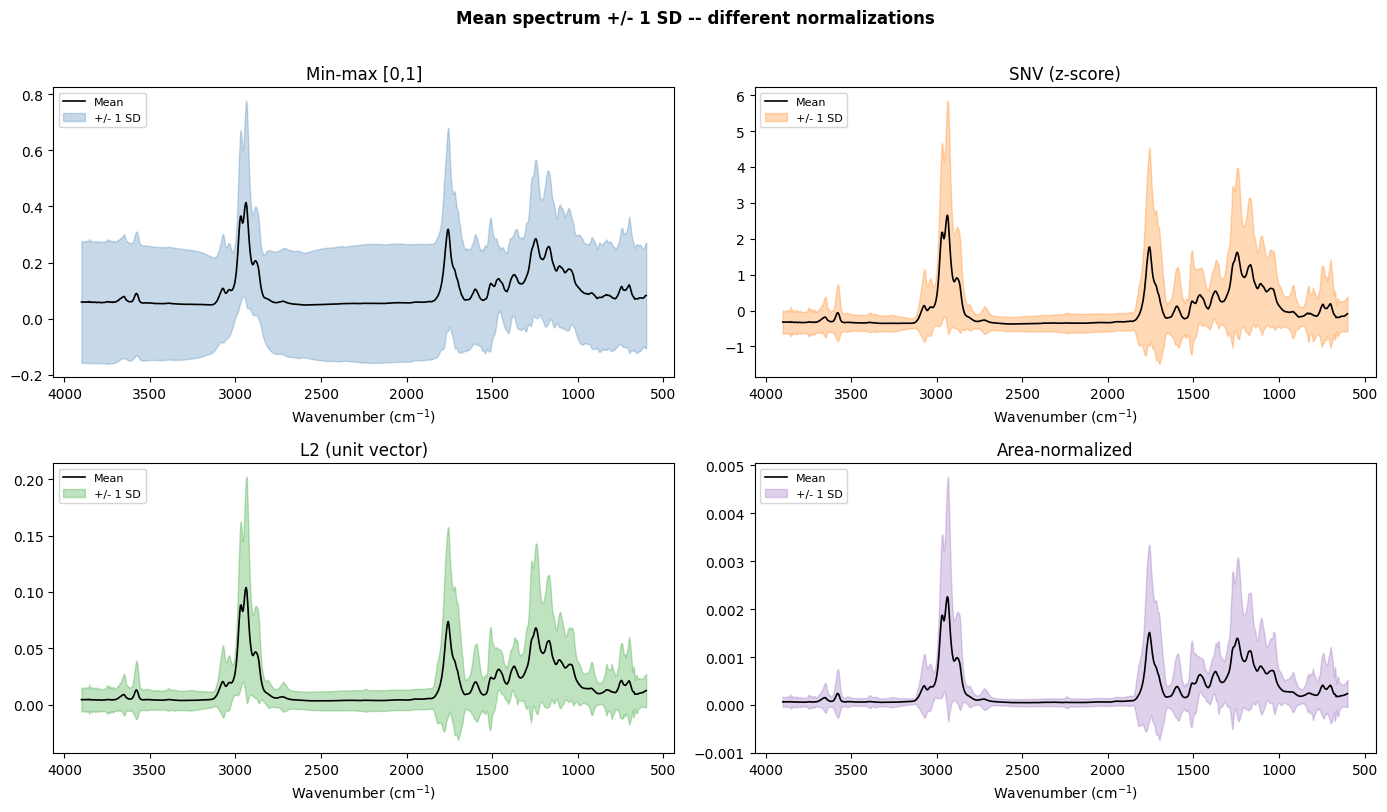

In [31]:
# Compare mean spectra under each normalization
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, arr), c in zip(axes.ravel(), norms.items(), colors):
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    ax.plot(common_wn, mean, color="k", lw=1.2, label="Mean")
    ax.fill_between(common_wn, mean - std, mean + std, alpha=0.3, color=c, label="+/- 1 SD")
    ax.invert_xaxis()
    ax.set_title(name)
    ax.set_xlabel("Wavenumber (cm$^{-1}$)")
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Mean spectrum +/- 1 SD -- different normalizations", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 7. Save ML-ready matrix

In [32]:
# Save the interpolated matrix (raw)
out_path = DATA_DIR / "ir_spectra_matrix.csv"
X.to_csv(out_path)
print(f"Saved {X.shape[0]} x {X.shape[1]} matrix to {out_path}")
print(f"Each row = one molecule (CID), each column = transmittance at a wavenumber")

Saved 234 x 800 matrix to data\ir_spectra_matrix.csv
Each row = one molecule (CID), each column = transmittance at a wavenumber
